모델 배포 개론 08  
Last modified : 2026.03   
작성 : 박광성 (모두의연구소)  
수정 : 김지성 (모두의연구소)  

In [43]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    # 모델 로드 때문에 기동이 느릴 수 있다 — 최대 5분 대기 (첫 실행은 다운로드 포함)
    for i in range(600):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        if not thread.is_alive():
            print('서버 스레드가 종료됐습니다. 위 로그를 확인하세요.')
            return server
        if i > 0 and i % 20 == 0:
            print(f'  ... 모델 로드 중 ({i//2}초 경과)')
        time.sleep(0.5)
    print('5분 내에 서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


# Day 8 — 자율 프로젝트: 나만의 모델 서빙 서비스 만들기

---

> **오늘의 목표**
>
> Day 1~7에서 배운 기술을 조합하여, 본인이 관심 있는 도메인의 모델을 서빙하는 서비스를 직접 만듭니다.  
> 따라하기가 아닌, **스스로 설계하고 구현하는** 첫 경험입니다.

---



## 1. 프로젝트 요구사항

---

### 1.1 조건

Day 5(주택 가격 예측)와 Day 6~7(이미지 분류 / 챗봇)에서 만든 서비스와 **동일한 구조**를 기본 베이스로 합니다. 

```
필수 구현 항목:

1. FastAPI 백엔드
   - 추론 엔드포인트 (POST /predict)
   - Pydantic으로 입력 검증
   - 비동기 추론 (run_in_executor)

2. API Key 인증
   - Day 6의 auth.py 재사용

3. Streamlit 프론트엔드
   - 사용자 입력 → API 호출 → 결과 표시

4. 에러 처리
   - 잘못된 입력, 모델 에러 시 적절한 HTTP 상태 코드 반환
```



### 1.2 제한 사항

```
하지 않는 것:

- 모델 학습 (사전학습 모델을 가져다 씁니다)
- Docker 패키징 (MLOps 과정에서 다룹니다)
- 데이터베이스 연동
```



### 1.3 평가 기준

```
✅ 서버가 정상적으로 실행되는가?
✅ Swagger UI에서 추론이 동작하는가?
✅ API Key 없이 요청하면 401이 반환되는가?
✅ 잘못된 입력에 대해 적절한 에러 메시지가 나오는가?
✅ Streamlit UI에서 입력 → 결과 확인이 가능한가?
```

---

## 2. 모델 선택 가이드

---

### 2.1 Hugging Face에서 모델 찾기

[Hugging Face Models](https://huggingface.co/models)에서 사전학습 모델을 선택합니다.
모델 학습은 하지 않고, `from_pretrained()`으로 바로 사용할 수 있는 모델을 고릅니다.

**모델 선택 시 확인할 것:**

```
1. 태스크가 명확한가? (text-classification, image-classification, summarization 등)
2. 한국어를 지원하는가? (필수는 아니지만, 데모가 직관적입니다)
3. 모델 크기가 적당한가? (CPU 환경이면 500MB 이하를 권장합니다)
4. pipeline()으로 바로 사용 가능한가?
```



### 2.2 도메인별 추천 예시

아래는 예시일 뿐입니다. **본인이 관심 있는 도메인을 자유롭게 선택하세요.**

| 도메인 | 태스크 | 추천 모델 (예시) |
|---|---|---|
| 감정 분석 | `text-classification` | `snunlp/KR-FinBert-SC` |
| 뉴스 분류 | `text-classification` | 원하는 분류 모델 |
| 텍스트 요약 | `summarization` | `eenzeenee/t5-base-korean` |
| 번역 | `translation` | `Helsinki-NLP` 시리즈 |
| 이미지 분류 | `image-classification` | `google/vit-base-patch16` |
| 객체 탐지 | `object-detection` | `facebook/detr-resnet-50` |
| 질의 응답 | `question-answering` | 원하는 QA 모델 |


### 선택한 프로젝트: Traffic Instinct Radar

**도메인:** 뉴스/콘텐츠/투자 심리 분석  
**태스크:** 다국어 zero-shot text classification  
**사용 모델:** `MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7`  

이 서비스는 뉴스 제목이나 콘텐츠 문장을 입력받아 다음 다섯 가지 관점으로 분석합니다.

1. 투자 심리: 호재, 악재, 과열, 불확실성 등
2. 클릭 자극: 돈 욕망, 공포, 분노, 호기심 갭 등
3. 신뢰 리스크: 사실 보도, 추측성 주장, 과장 표현, 근거 부족 등
4. 타깃 독자: 주식 투자자, 일반 대중, 사업가, 기술 업계 종사자 등
5. 콘텐츠 각도: 투자 기회형, 위험 경고형, 트렌드 해설형 등



### 2.3 모델 동작 확인

모델을 선택했으면, **서버 코드를 작성하기 전에** 노트북에서 먼저 동작을 확인합니다.

In [44]:
# Traffic Instinct Radar — 모델 동작 확인
# 뉴스/콘텐츠 제목을 입력하면 클릭 자극, 투자 심리, 신뢰 리스크를 zero-shot 방식으로 분류합니다.
from transformers import pipeline

MODEL_NAME = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"

classifier = pipeline(
    task="zero-shot-classification",
    model=MODEL_NAME,
    device=0,  # CPU 사용. GPU 환경이면 0으로 변경 가능
)

sample_text = "삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감"

traffic_labels = [
    "돈 욕망 자극",
    "공포 자극",
    "분노 자극",
    "호기심 갭",
    "권위 호소",
    "실용 정보",
    "낚시성 제목",
]

result = classifier(
    sample_text,
    candidate_labels=traffic_labels,
    hypothesis_template="이 문장은 {} 성격을 가진다.",
    multi_label=False,
)

print("입력:", sample_text)
print("가장 높은 라벨:", result["labels"][0])
print("신뢰도:", round(result["scores"][0], 4))
print("전체 결과:")
for label, score in zip(result["labels"], result["scores"]):
    print(f"- {label}: {score:.4f}")


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 11975.76it/s]


입력: 삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감
가장 높은 라벨: 돈 욕망 자극
신뢰도: 0.4344
전체 결과:
- 돈 욕망 자극: 0.4344
- 낚시성 제목: 0.1655
- 호기심 갭: 0.1507
- 실용 정보: 0.1235
- 권위 호소: 0.1035
- 분노 자극: 0.0125
- 공포 자극: 0.0098


예시 코드입니다. 샘플 이미지 파일이 있어야 실행됩니다.

```python
# 예시: 이미지 분류
from transformers import pipeline

classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

result = classifier("test_image.jpg")
print(result)
# [{'label': 'tabby cat', 'score': 0.82}, ...]
```

> **이 셀이 정상 동작하면**, 서버 코드 작성으로 넘어갑니다.
> 여기서 에러가 나면, 모델을 바꾸거나 입력 형식을 확인하세요.



---

## 3. 프로젝트 뼈대 코드

---



### 3.1 폴더 구조

In [45]:
import os

dirs = ["app", "models", "frontend"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("프로젝트 구조:")
print("""
my-project/
├── 📁 app/
│   ├── auth.py              ← Day 6에서 만든 것 그대로 재사용
│   ├── schemas.py           ← 입력/출력 스키마 정의 (직접 작성)
│   ├── model_service.py     ← 모델 로드 + 추론 함수 (직접 작성)
│   └── main.py              ← FastAPI 서버 (직접 작성)
│
├── 📁 frontend/
│   └── app.py               ← Streamlit UI (직접 작성)
│
└── requirements.txt
""")

프로젝트 구조:

my-project/
├── 📁 app/
│   ├── auth.py              ← Day 6에서 만든 것 그대로 재사용
│   ├── schemas.py           ← 입력/출력 스키마 정의 (직접 작성)
│   ├── model_service.py     ← 모델 로드 + 추론 함수 (직접 작성)
│   └── main.py              ← FastAPI 서버 (직접 작성)
│
├── 📁 frontend/
│   └── app.py               ← Streamlit UI (직접 작성)
│
└── requirements.txt



In [46]:
%%writefile requirements.txt
fastapi
uvicorn
streamlit
requests
transformers
torch
sentencepiece
protobuf
accelerate
pydantic


Overwriting requirements.txt


### 3.2 auth.py — 재사용

In [47]:
%%writefile app/auth.py
"""
Day 6에서 만든 인증 모듈을 그대로 재사용합니다.
"""
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

Overwriting app/auth.py


### 3.3 schemas.py — 직접 작성

In [48]:
%%writefile app/schemas.py
"""
Traffic Instinct Radar 입력/출력 스키마

뉴스 제목 또는 콘텐츠 제목을 입력받아
투자 심리, 클릭 자극, 신뢰 리스크, 타깃 독자, 콘텐츠 각도를 반환합니다.
"""
from typing import Optional
from pydantic import BaseModel, Field


class PredictRequest(BaseModel):
    title: str = Field(
        ...,
        min_length=2,
        max_length=300,
        description="분석할 뉴스 제목 또는 콘텐츠 제목",
    )
    body: Optional[str] = Field(
        default="",
        max_length=3000,
        description="선택 입력: 기사 요약문 또는 본문 일부",
    )


class LabelScore(BaseModel):
    label: str
    score: float = Field(..., ge=0.0, le=1.0)


class PredictResponse(BaseModel):
    success: bool
    input_preview: str
    market_sentiment: LabelScore
    traffic_trigger: LabelScore
    trust_risk: LabelScore
    target_reader: LabelScore
    content_angle: LabelScore
    click_power_score: float = Field(..., ge=0.0, le=100.0)
    caution_note: str


Overwriting app/schemas.py


### 3.4 model_service.py — 직접 작성

In [49]:
%%writefile app/model_service.py
"""
Traffic Instinct Radar 모델 로드 및 추론 로직

사용 모델:
- MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7

방식:
- zero-shot-classification
- 별도 학습 없이 후보 라벨을 바꿔가며 여러 관점으로 분류
"""
from transformers import pipeline


MODEL_NAME = "MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7"

MARKET_LABELS = [
    "강한 호재",
    "약한 호재",
    "중립",
    "약한 악재",
    "강한 악재",
    "과열",
    "불확실성",
]

TRAFFIC_LABELS = [
    "돈 욕망 자극",
    "공포 자극",
    "분노 자극",
    "호기심 갭",
    "권위 호소",
    "실용 정보",
    "낚시성 제목",
]

TRUST_LABELS = [
    "사실 보도",
    "분석 의견",
    "추측성 주장",
    "광고성 문장",
    "과장된 표현",
    "근거 부족",
]

TARGET_LABELS = [
    "주식 투자자",
    "일반 대중",
    "사업가",
    "정치 관심층",
    "기술 업계 종사자",
    "콘텐츠 소비자",
]

ANGLE_LABELS = [
    "투자 기회형",
    "위험 경고형",
    "정보 요약형",
    "논란 확산형",
    "트렌드 해설형",
    "실용 가이드형",
]

RISKY_TRUST_LABELS = {"추측성 주장", "광고성 문장", "과장된 표현", "근거 부족"}
STRONG_TRAFFIC_LABELS = {"돈 욕망 자극", "공포 자극", "분노 자극", "호기심 갭", "낚시성 제목"}


def load_model():
    """Hugging Face zero-shot classification 파이프라인을 로드합니다."""
    return pipeline(
        task="zero-shot-classification",
        model=MODEL_NAME,
        device=-1,  # CPU 사용. GPU 환경이면 0으로 변경 가능
    )


def _classify(classifier, text: str, labels: list[str]) -> dict:
    """후보 라벨 중 가장 높은 점수의 라벨과 점수를 반환합니다."""
    result = classifier(
        text,
        candidate_labels=labels,
        hypothesis_template="이 문장은 {} 성격을 가진다.",
        multi_label=False,
    )
    return {
        "label": result["labels"][0],
        "score": round(float(result["scores"][0]), 4),
    }


def _calculate_click_power(traffic: dict, trust: dict, market: dict) -> float:
    """클릭 유도력을 0~100 점수로 계산합니다."""
    score = traffic["score"] * 70

    if traffic["label"] in STRONG_TRAFFIC_LABELS:
        score += 10

    if trust["label"] in RISKY_TRUST_LABELS:
        score += trust["score"] * 15

    if market["label"] in {"강한 호재", "강한 악재", "과열", "불확실성"}:
        score += market["score"] * 5

    return round(min(score, 100.0), 2)


def _make_caution_note(trust: dict) -> str:
    if trust["label"] in RISKY_TRUST_LABELS:
        return "클릭 유도력은 있으나 신뢰 리스크가 있습니다. 실제 서비스에서는 출처, 수치, 근거 문장을 함께 제시해야 합니다."
    return "신뢰 리스크는 상대적으로 낮지만, 이 결과는 모델 추론이므로 최종 판단에는 원문 확인이 필요합니다."


def predict(model, title: str, body: str = "") -> dict:
    """입력 텍스트를 여러 관점으로 분류합니다."""
    title = title.strip()
    body = (body or "").strip()

    if len(title) < 2:
        raise ValueError("title은 최소 2글자 이상이어야 합니다.")

    text = title if not body else f"{title}\n\n{body}"

    market = _classify(model, text, MARKET_LABELS)
    traffic = _classify(model, text, TRAFFIC_LABELS)
    trust = _classify(model, text, TRUST_LABELS)
    target = _classify(model, text, TARGET_LABELS)
    angle = _classify(model, text, ANGLE_LABELS)

    click_power = _calculate_click_power(traffic, trust, market)

    return {
        "success": True,
        "input_preview": text[:120],
        "market_sentiment": market,
        "traffic_trigger": traffic,
        "trust_risk": trust,
        "target_reader": target,
        "content_angle": angle,
        "click_power_score": click_power,
        "caution_note": _make_caution_note(trust),
    }


Overwriting app/model_service.py


### 3.5 main.py — 직접 작성

In [50]:
%%writefile app/main.py
"""
Traffic Instinct Radar FastAPI 서버

개선점:
- 서버 시작 시 모델을 바로 로드하지 않습니다.
- /health 는 즉시 응답합니다.
- /predict 첫 호출 때 모델을 lazy loading 합니다.
- 첫 다운로드/로드가 오래 걸려도 백엔드 연결 거부가 나지 않게 합니다.
"""
import asyncio
import threading
from concurrent.futures import ThreadPoolExecutor
from fastapi import FastAPI, Depends, HTTPException

from app.auth import verify_api_key
from app.schemas import PredictRequest, PredictResponse
from app.model_service import load_model, predict


app = FastAPI(
    title="Traffic Instinct Radar API",
    description="뉴스 제목과 콘텐츠 문장의 투자심리·클릭자극·신뢰리스크를 분석하는 AI 모델 서빙 서비스",
    version="1.1.0",
)

executor = ThreadPoolExecutor(max_workers=2)
_model = None
_model_error = None
_model_lock = threading.Lock()


def get_model():
    """모델을 최초 1회만 로드합니다. 첫 로드는 오래 걸릴 수 있습니다."""
    global _model, _model_error

    if _model is not None:
        return _model

    with _model_lock:
        if _model is not None:
            return _model
        try:
            _model = load_model()
            _model_error = None
            return _model
        except Exception as e:
            _model_error = repr(e)
            raise


def predict_with_lazy_model(title: str, body: str):
    model = get_model()
    return predict(model, title, body)


@app.get("/health")
async def health_check():
    return {
        "status": "ok",
        "model_loaded": _model is not None,
        "model_error": _model_error,
        "service": "Traffic Instinct Radar",
    }


@app.post("/warmup")
async def warmup_model():
    """검증용: 모델을 미리 로드합니다."""
    loop = asyncio.get_running_loop()
    try:
        await loop.run_in_executor(executor, get_model)
        return {"status": "ok", "model_loaded": _model is not None}
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"모델 로드 실패: {str(e)}")


@app.post("/predict", response_model=PredictResponse)
async def predict_endpoint(
    request: PredictRequest,
    user: str = Depends(verify_api_key),
):
    """API Key 인증 후 입력 문장을 분석합니다."""
    loop = asyncio.get_running_loop()

    try:
        result = await loop.run_in_executor(
            executor,
            predict_with_lazy_model,
            request.title,
            request.body or "",
        )
        return result
    except ValueError as e:
        raise HTTPException(status_code=400, detail=str(e))
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"모델 추론 중 오류가 발생했습니다: {str(e)}")


Overwriting app/main.py


### 3.6 frontend/app.py — UI/UX 개선 버전

단순 JSON 출력이 아니라, 대시보드형 카드·점수바·분석 요약·발행 전 체크리스트를 보여주는 Streamlit UI입니다.

In [51]:
%%writefile frontend/app.py
"""
Traffic Instinct Radar Streamlit 프론트엔드 - UI/UX 개선 버전
"""
import html
from typing import Dict, Any

import requests
import streamlit as st


DEFAULT_API_URL = "http://localhost:8000"
DEFAULT_API_KEY = "test-key-001"

EXAMPLES = {
    "반도체 호재형": {
        "title": "삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감",
        "body": "AI 서버 투자 확대와 HBM 수요 증가로 반도체 업황 개선 기대감이 커지고 있다.",
    },
    "정치 이슈형": {
        "title": "대통령 긴급 담화 이후 여야 충돌 격화",
        "body": "정책 방향을 둘러싼 논란이 커지며 지지층 결집과 반발 여론이 동시에 확산되고 있다.",
    },
    "경제 불안형": {
        "title": "환율 급등에 수입 물가 비상, 서민 부담 커진다",
        "body": "원화 약세와 국제 원자재 가격 상승이 겹치며 생활 물가 상승 압력이 커지고 있다.",
    },
    "기술 트렌드형": {
        "title": "오픈AI 신모델 공개, 검색과 업무 자동화 시장 흔든다",
        "body": "생성형 AI의 추론 성능과 에이전트 기능이 강화되면서 기업용 소프트웨어 시장의 재편 가능성이 제기된다.",
    },
}

st.set_page_config(
    page_title="Traffic Instinct Radar",
    page_icon="TIR",
    layout="wide",
    initial_sidebar_state="expanded",
)

st.markdown(
    """
    <style>
    :root {
        --bg-soft: #f6f8fc;
        --card: #ffffff;
        --line: #e5e7eb;
        --text: #111827;
        --muted: #6b7280;
        --blue: #2563eb;
        --green: #059669;
        --orange: #ea580c;
        --red: #dc2626;
        --purple: #7c3aed;
        --slate: #334155;
    }
    .block-container {
        padding-top: 2rem;
        padding-bottom: 4rem;
        max-width: 1180px;
    }
    .main-hero {
        padding: 28px 32px;
        border-radius: 26px;
        color: white;
        background: linear-gradient(135deg, #0f172a 0%, #1e3a8a 48%, #7c3aed 100%);
        box-shadow: 0 18px 42px rgba(15, 23, 42, 0.22);
        margin-bottom: 24px;
    }
    .hero-kicker {
        font-size: 13px;
        letter-spacing: 0.12em;
        text-transform: uppercase;
        opacity: 0.78;
        margin-bottom: 8px;
    }
    .hero-title {
        font-size: 42px;
        font-weight: 850;
        line-height: 1.08;
        margin: 0 0 10px 0;
    }
    .hero-subtitle {
        font-size: 16px;
        opacity: 0.9;
        max-width: 780px;
        line-height: 1.65;
    }
    .section-title {
        font-size: 22px;
        font-weight: 800;
        margin: 10px 0 14px 0;
        color: var(--text);
    }
    .card {
        background: var(--card);
        border: 1px solid var(--line);
        border-radius: 20px;
        padding: 20px 22px;
        box-shadow: 0 8px 24px rgba(15, 23, 42, 0.06);
        margin-bottom: 14px;
    }
    .metric-card {
        background: var(--card);
        border: 1px solid var(--line);
        border-radius: 18px;
        padding: 18px 20px;
        height: 128px;
        box-shadow: 0 8px 22px rgba(15, 23, 42, 0.055);
    }
    .metric-label {
        font-size: 13px;
        color: var(--muted);
        margin-bottom: 8px;
    }
    .metric-value {
        font-size: 28px;
        font-weight: 850;
        color: var(--text);
        line-height: 1.15;
    }
    .metric-sub {
        font-size: 12px;
        color: var(--muted);
        margin-top: 8px;
    }
    .pill {
        display: inline-block;
        padding: 6px 10px;
        border-radius: 999px;
        font-size: 12px;
        font-weight: 750;
        border: 1px solid transparent;
    }
    .pill-blue { background: #dbeafe; color: #1d4ed8; border-color: #bfdbfe; }
    .pill-green { background: #d1fae5; color: #047857; border-color: #a7f3d0; }
    .pill-orange { background: #ffedd5; color: #c2410c; border-color: #fed7aa; }
    .pill-red { background: #fee2e2; color: #b91c1c; border-color: #fecaca; }
    .pill-purple { background: #ede9fe; color: #6d28d9; border-color: #ddd6fe; }
    .pill-slate { background: #e2e8f0; color: #334155; border-color: #cbd5e1; }
    .result-row {
        display: grid;
        grid-template-columns: 170px 1fr 70px;
        gap: 14px;
        align-items: center;
        margin: 14px 0;
    }
    .row-title {
        color: var(--slate);
        font-weight: 800;
        font-size: 14px;
    }
    .bar-wrap {
        width: 100%;
        height: 12px;
        background: #e5e7eb;
        border-radius: 999px;
        overflow: hidden;
    }
    .bar-fill {
        height: 12px;
        border-radius: 999px;
        background: linear-gradient(90deg, #2563eb, #7c3aed);
    }
    .score-text {
        text-align: right;
        font-size: 13px;
        font-weight: 800;
        color: var(--slate);
    }
    .summary-box {
        background: #f8fafc;
        border: 1px solid #e2e8f0;
        border-radius: 18px;
        padding: 18px 20px;
        line-height: 1.75;
        color: #1f2937;
    }
    .small-muted {
        color: var(--muted);
        font-size: 13px;
        line-height: 1.6;
    }
    div.stButton > button:first-child {
        width: 100%;
        height: 3.1rem;
        border-radius: 14px;
        font-weight: 800;
        font-size: 16px;
    }
    textarea {
        border-radius: 14px !important;
    }
    </style>
    """,
    unsafe_allow_html=True,
)


def esc(value: Any) -> str:
    return html.escape(str(value))


def get_label_score(result: Dict[str, Any], key: str) -> tuple[str, float]:
    item = result.get(key, {}) or {}
    label = item.get("label", "-")
    score = float(item.get("score", 0.0) or 0.0)
    return str(label), score


def pill_class(kind: str, label: str) -> str:
    if kind == "trust":
        if label in {"추측성 주장", "광고성 문장", "과장된 표현", "근거 부족"}:
            return "pill-red"
        if label == "분석 의견":
            return "pill-orange"
        return "pill-green"
    if kind == "traffic":
        if label in {"돈 욕망 자극", "공포 자극", "분노 자극", "낚시성 제목"}:
            return "pill-orange"
        if label == "호기심 갭":
            return "pill-purple"
        return "pill-blue"
    if kind == "market":
        if label in {"강한 호재", "약한 호재"}:
            return "pill-green"
        if label in {"강한 악재", "약한 악재", "불확실성"}:
            return "pill-red"
        if label == "과열":
            return "pill-orange"
        return "pill-slate"
    return "pill-blue"


def render_metric(title: str, value: str, sub: str = ""):
    st.markdown(
        f"""
        <div class="metric-card">
            <div class="metric-label">{esc(title)}</div>
            <div class="metric-value">{esc(value)}</div>
            <div class="metric-sub">{esc(sub)}</div>
        </div>
        """,
        unsafe_allow_html=True,
    )


def render_result_row(title: str, label: str, score: float, kind: str = "basic"):
    pct = max(0, min(score * 100, 100))
    badge = pill_class(kind, label)
    st.markdown(
        f"""
        <div class="result-row">
            <div class="row-title">{esc(title)}</div>
            <div>
                <span class="pill {badge}">{esc(label)}</span>
                <div style="height:8px"></div>
                <div class="bar-wrap"><div class="bar-fill" style="width:{pct:.1f}%"></div></div>
            </div>
            <div class="score-text">{pct:.1f}%</div>
        </div>
        """,
        unsafe_allow_html=True,
    )


def click_level(score: float) -> str:
    if score >= 75:
        return "강함"
    if score >= 50:
        return "보통 이상"
    if score >= 30:
        return "보통"
    return "낮음"


def make_summary(result: Dict[str, Any]) -> str:
    market, market_score = get_label_score(result, "market_sentiment")
    traffic, traffic_score = get_label_score(result, "traffic_trigger")
    trust, trust_score = get_label_score(result, "trust_risk")
    target, target_score = get_label_score(result, "target_reader")
    angle, angle_score = get_label_score(result, "content_angle")
    click = float(result.get("click_power_score", 0.0) or 0.0)

    return (
        f"이 콘텐츠는 <b>{esc(target)}</b>에게 가장 잘 반응할 가능성이 높고, "
        f"핵심 자극은 <b>{esc(traffic)}</b>입니다. "
        f"투자 심리는 <b>{esc(market)}</b>으로 분류되며, "
        f"콘텐츠 각도는 <b>{esc(angle)}</b>에 가깝습니다. "
        f"클릭 유도력은 <b>{click:.2f}점</b>으로 <b>{esc(click_level(click))}</b> 수준입니다. "
        f"단, 신뢰 리스크가 <b>{esc(trust)}</b>로 감지되었으므로 제목을 강화하더라도 근거 문장을 함께 제시하는 것이 좋습니다."
    )


def render_checklist(result: Dict[str, Any]):
    click = float(result.get("click_power_score", 0.0) or 0.0)
    trust, _ = get_label_score(result, "trust_risk")
    traffic, _ = get_label_score(result, "traffic_trigger")

    checks = []
    if click >= 70:
        checks.append("클릭 유도력이 높습니다. 제목은 살리고 본문 첫 문단에 근거를 보강하십시오.")
    elif click >= 45:
        checks.append("클릭 유도력은 보통 이상입니다. 숫자, 비교, 결과를 제목에 추가하면 더 강해집니다.")
    else:
        checks.append("클릭 유도력이 약합니다. 독자가 얻는 이익이나 손실을 제목에 더 직접적으로 넣으십시오.")

    if trust in {"추측성 주장", "광고성 문장", "과장된 표현", "근거 부족"}:
        checks.append("신뢰 리스크가 있습니다. 출처, 수치, 실제 인용문을 반드시 붙이십시오.")
    else:
        checks.append("신뢰 리스크는 낮은 편입니다. 현재 톤을 유지해도 됩니다.")

    if traffic in {"돈 욕망 자극", "공포 자극", "분노 자극"}:
        checks.append("강한 감정 자극형입니다. 과도하게 몰아가면 낚시성으로 보일 수 있습니다.")
    else:
        checks.append("자극 강도는 비교적 안정적입니다. 정보성과 호기심을 함께 밀면 좋습니다.")

    for item in checks:
        st.markdown(f"- {item}")


with st.sidebar:
    st.markdown("### API 설정")
    api_key = st.text_input("API Key", value=DEFAULT_API_KEY, type="password")
    api_url = st.text_input("API URL", value=DEFAULT_API_URL)

    st.divider()
    st.markdown("### 예시 입력")
    selected_example = st.selectbox("샘플 선택", list(EXAMPLES.keys()))

    if st.button("샘플 불러오기"):
        st.session_state["title"] = EXAMPLES[selected_example]["title"]
        st.session_state["body"] = EXAMPLES[selected_example]["body"]

    st.divider()
    if st.button("백엔드 상태 확인"):
        try:
            health = requests.get(f"{api_url}/health", timeout=5)
            if health.status_code == 200:
                data = health.json()
                st.success(f"연결 정상 / model_loaded={data.get('model_loaded')}")
            else:
                st.error(f"상태 코드: {health.status_code}")
        except requests.exceptions.RequestException as e:
            st.error(f"연결 실패: {e}")

    st.caption("FastAPI 백엔드가 8000번 포트에서 실행 중이어야 합니다.")

if "title" not in st.session_state:
    st.session_state["title"] = EXAMPLES["반도체 호재형"]["title"]
if "body" not in st.session_state:
    st.session_state["body"] = EXAMPLES["반도체 호재형"]["body"]

st.markdown(
    """
    <div class="main-hero">
        <div class="hero-kicker">AI Content Intelligence</div>
        <div class="hero-title">Traffic Instinct Radar</div>
        <div class="hero-subtitle">
            뉴스 제목과 콘텐츠 문장을 입력하면 투자 심리, 클릭 자극, 신뢰 리스크, 타깃 독자, 콘텐츠 각도를 한 번에 분류합니다.
            단순 감정분석이 아니라 발행 전 의사결정용 콘텐츠 레이더입니다.
        </div>
    </div>
    """,
    unsafe_allow_html=True,
)

input_col, guide_col = st.columns([1.45, 0.85], gap="large")

with input_col:
    st.markdown('<div class="section-title">분석할 콘텐츠</div>', unsafe_allow_html=True)
    with st.container(border=True):
        title = st.text_area(
            "뉴스 제목 또는 콘텐츠 제목",
            key="title",
            height=90,
            placeholder="예: 삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감",
        )
        body = st.text_area(
            "본문 또는 요약문 선택 입력",
            key="body",
            height=150,
            placeholder="기사 요약문이나 본문 일부를 입력하면 분류 품질이 더 좋아집니다.",
        )
        analyze = st.button("분석 실행", type="primary")

with guide_col:
    st.markdown('<div class="section-title">분석 관점</div>', unsafe_allow_html=True)
    st.markdown(
        """
        <div class="card">
            <span class="pill pill-green">투자 심리</span>
            <p class="small-muted">호재, 악재, 과열, 불확실성을 분류합니다.</p>
            <span class="pill pill-orange">클릭 자극</span>
            <p class="small-muted">돈 욕망, 공포, 분노, 호기심, 낚시성을 봅니다.</p>
            <span class="pill pill-red">신뢰 리스크</span>
            <p class="small-muted">추측, 과장, 광고성, 근거 부족 여부를 탐지합니다.</p>
            <span class="pill pill-purple">콘텐츠 각도</span>
            <p class="small-muted">투자 기회형, 위험 경고형, 트렌드 해설형 등으로 분류합니다.</p>
        </div>
        """,
        unsafe_allow_html=True,
    )

if analyze:
    if not st.session_state["title"].strip():
        st.warning("제목을 입력해 주세요.")
        st.stop()

    headers = {"X-API-Key": api_key}
    payload = {"title": st.session_state["title"], "body": st.session_state["body"]}

    with st.spinner("모델이 콘텐츠를 분석하는 중입니다. 첫 실행은 모델 로딩 때문에 시간이 걸릴 수 있습니다."):
        try:
            response = requests.post(
                f"{api_url}/predict",
                json=payload,
                headers=headers,
                timeout=120,
            )
        except requests.exceptions.RequestException as e:
            st.error(f"API 서버에 연결할 수 없습니다: {e}")
            st.stop()

    if response.status_code != 200:
        st.error(f"API 오류: {response.status_code}")
        try:
            st.json(response.json())
        except Exception:
            st.code(response.text)
        st.stop()

    result = response.json()

    market, market_score = get_label_score(result, "market_sentiment")
    traffic, traffic_score = get_label_score(result, "traffic_trigger")
    trust, trust_score = get_label_score(result, "trust_risk")
    target, target_score = get_label_score(result, "target_reader")
    angle, angle_score = get_label_score(result, "content_angle")
    click = float(result.get("click_power_score", 0.0) or 0.0)

    st.markdown('<div class="section-title">분석 대시보드</div>', unsafe_allow_html=True)
    m1, m2, m3, m4 = st.columns(4)
    with m1:
        render_metric("클릭 유도력", f"{click:.2f}", f"수준: {click_level(click)}")
    with m2:
        render_metric("투자 심리", market, f"확신도 {market_score * 100:.1f}%")
    with m3:
        render_metric("핵심 자극", traffic, f"확신도 {traffic_score * 100:.1f}%")
    with m4:
        render_metric("신뢰 리스크", trust, f"확신도 {trust_score * 100:.1f}%")

    st.progress(min(click / 100, 1.0), text=f"클릭 유도력 점수 {click:.2f} / 100")

    left, right = st.columns([1.1, 0.9], gap="large")
    with left:
        st.markdown('<div class="section-title">분석 요약</div>', unsafe_allow_html=True)
        st.markdown(f'<div class="summary-box">{make_summary(result)}</div>', unsafe_allow_html=True)

        st.markdown('<div class="section-title">발행 전 체크리스트</div>', unsafe_allow_html=True)
        with st.container(border=True):
            render_checklist(result)
            st.info(result.get("caution_note", "최종 판단에는 원문 확인이 필요합니다."))

    with right:
        st.markdown('<div class="section-title">분류 상세</div>', unsafe_allow_html=True)
        with st.container(border=True):
            render_result_row("투자 심리", market, market_score, "market")
            render_result_row("클릭 자극 요소", traffic, traffic_score, "traffic")
            render_result_row("신뢰 리스크", trust, trust_score, "trust")
            render_result_row("타깃 독자", target, target_score, "target")
            render_result_row("콘텐츠 각도", angle, angle_score, "angle")

    with st.expander("원본 API 응답 JSON 보기"):
        st.json(result)
else:
    st.markdown('<div class="section-title">대기 상태</div>', unsafe_allow_html=True)
    st.markdown(
        """
        <div class="card">
            <b>분석 실행</b> 버튼을 누르면 FastAPI 백엔드의 <code>/predict</code> 엔드포인트로 요청을 보내고,
            반환된 분류 결과를 대시보드 형태로 표시합니다.
        </div>
        """,
        unsafe_allow_html=True,
    )


Overwriting frontend/app.py


---

## 4. 작업 시간

---

### 4.1 권장 순서



```
Step 1. 모델 선택 + 노트북에서 동작 확인 (섹션 2.3)
        → "이 모델이 내 입력에 대해 결과를 반환하는가?"

Step 2. schemas.py 작성
        → "입력과 출력의 형태를 정의"

Step 3. model_service.py 작성
        → "모델 로드 + 추론 함수"

Step 4. main.py 작성
        → "FastAPI 서버 조립"

Step 5. 서버 실행 + Swagger UI 테스트
        → "API가 동작하는가?"

Step 6. frontend/app.py 작성
        → "Streamlit UI 연결"
```



### 4.2 서버 실행 (Step 5에서 사용)

> ⚠️ **코드를 수정했는데 반영이 안 될 때 — 커널을 재시작하세요.**
>
> `app/main.py`, `app/model_service.py` 등을 고친 뒤 아래 셀을 다시 실행해도,
> 이미 메모리에 올라간 이전 코드가 남아 변경이 반영되지 않을 수 있습니다.
> 코드를 수정했다면 **커널 재시작(Kernel → Restart) 후 맨 위 셀부터 다시 실행**하세요.

In [52]:
# FastAPI 백엔드 실행
# 이 셀은 백엔드만 띄웁니다. 모델은 /warmup 또는 /predict 호출 때 로드됩니다.
server = serve_in_thread("app.main:app", port=8000, log_level="info")


⚠️ 포트 8000를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).
   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.


### 4.2.1 Streamlit 프론트엔드 실행 — 노트북 내부 실행

아래 셀은 터미널을 따로 열지 않고, 노트북 안에서 `frontend/app.py`를 백그라운드 프로세스로 실행합니다.  
백엔드는 `http://127.0.0.1:8000`, 프론트엔드는 `http://127.0.0.1:8501`로 실행됩니다.


In [53]:
# Streamlit 프론트엔드 실행 — 노트북 안에서 백그라운드로 실행
# 먼저 위의 파일 생성 셀들(app/*.py, frontend/app.py)과 백엔드 실행 셀을 실행한 뒤 이 셀을 실행하세요.
import os
import sys
import time
import socket
import contextlib
import subprocess
from IPython.display import IFrame, display

FRONTEND_HOST = "127.0.0.1"
FRONTEND_PORT = 8501
FRONTEND_URL = f"http://{FRONTEND_HOST}:{FRONTEND_PORT}"
FRONTEND_PATH = os.path.abspath("frontend/app.py")


def _is_port_open(host: str, port: int) -> bool:
    with contextlib.closing(socket.socket(socket.AF_INET, socket.SOCK_STREAM)) as sock:
        sock.settimeout(0.5)
        return sock.connect_ex((host, port)) == 0


def stop_streamlit():
    """이 노트북에서 실행한 Streamlit 프로세스를 종료합니다."""
    proc = globals().get("_STREAMLIT_PROC")
    if proc is not None and proc.poll() is None:
        proc.terminate()
        try:
            proc.wait(timeout=5)
        except subprocess.TimeoutExpired:
            proc.kill()
    globals()["_STREAMLIT_PROC"] = None

    log_file = globals().get("_STREAMLIT_LOG_FILE")
    if log_file is not None and not log_file.closed:
        log_file.close()
    globals()["_STREAMLIT_LOG_FILE"] = None


if not os.path.exists(FRONTEND_PATH):
    raise FileNotFoundError(
        "frontend/app.py가 없습니다. 위쪽의 `%%writefile frontend/app.py` 셀을 먼저 실행하세요."
    )

# 이전에 이 노트북에서 띄운 Streamlit이 있으면 종료하고 새로 실행합니다.
stop_streamlit()

if _is_port_open(FRONTEND_HOST, FRONTEND_PORT):
    print(f"⚠️ 포트 {FRONTEND_PORT}가 이미 사용 중입니다. 기존 Streamlit 화면을 사용합니다: {FRONTEND_URL}")
else:
    _STREAMLIT_LOG_FILE = open("streamlit.log", "w", encoding="utf-8")
    cmd = [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        FRONTEND_PATH,
        "--server.address", FRONTEND_HOST,
        "--server.port", str(FRONTEND_PORT),
        "--server.headless", "true",
        "--browser.gatherUsageStats", "false",
    ]
    _STREAMLIT_PROC = subprocess.Popen(
        cmd,
        stdout=_STREAMLIT_LOG_FILE,
        stderr=subprocess.STDOUT,
    )

    for _ in range(90):
        if _is_port_open(FRONTEND_HOST, FRONTEND_PORT):
            break
        if _STREAMLIT_PROC.poll() is not None:
            raise RuntimeError("Streamlit 실행에 실패했습니다. 같은 폴더의 streamlit.log 파일을 확인하세요.")
        time.sleep(0.5)
    else:
        raise TimeoutError("Streamlit이 45초 안에 시작되지 않았습니다. streamlit.log 파일을 확인하세요.")

print(f"✅ Streamlit 프론트엔드 실행됨: {FRONTEND_URL}")
print("브라우저에서 직접 열어도 되고, 아래 임베드 화면에서 확인해도 됩니다.")
display(IFrame(FRONTEND_URL, width=1500, height=1500))


✅ Streamlit 프론트엔드 실행됨: http://127.0.0.1:8501
브라우저에서 직접 열어도 되고, 아래 임베드 화면에서 확인해도 됩니다.


### 4.2.2 백엔드 + 프론트엔드 + 분류 모델 통합 검증

아래 셀은 다음 3가지를 한 번에 확인합니다.

1. FastAPI 백엔드가 살아 있는가?
2. Streamlit 프론트엔드가 열려 있는가?
3. `/predict` 요청으로 실제 분류 결과가 반환되는가?


In [54]:
# 백엔드 + 프론트엔드 + 분류 모델 통합 검증
import time
import requests

BACKEND_URL = "http://127.0.0.1:8000"
FRONTEND_URL = "http://127.0.0.1:8501"
HEADERS = {"X-API-Key": "test-key-001"}


def wait_get(url: str, timeout_sec: int = 90):
    """서버가 열릴 때까지 대기한 뒤 GET 요청 결과를 반환합니다."""
    last_error = None
    deadline = time.time() + timeout_sec
    while time.time() < deadline:
        try:
            response = requests.get(url, timeout=5)
            return response
        except requests.exceptions.RequestException as e:
            last_error = e
            time.sleep(1)
    raise RuntimeError(f"서버 연결 실패: {url}\n마지막 오류: {last_error}")


print("[1] FastAPI 백엔드 상태 확인")
health = wait_get(f"{BACKEND_URL}/health", timeout_sec=120)
print("상태 코드:", health.status_code)
print("응답:", health.json())
assert health.status_code == 200

print("\n[2] Streamlit 프론트엔드 상태 확인")
front = wait_get(FRONTEND_URL, timeout_sec=60)
print("상태 코드:", front.status_code)
assert front.status_code < 500

print("\n[3] 모델 사전 로드 확인")
print("첫 실행이면 모델 다운로드/로드 때문에 몇 분 걸릴 수 있습니다.")
warm = requests.post(f"{BACKEND_URL}/warmup", timeout=600)
print("상태 코드:", warm.status_code)
print("응답:", warm.json())
assert warm.status_code == 200
assert warm.json().get("model_loaded") is True

print("\n[4] 분류 모델 추론 확인")
payload = {
    "title": "삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감",
    "body": "AI 서버 투자 확대와 HBM 수요 증가로 반도체 업황 개선 기대감이 커지고 있다.",
}
pred = requests.post(
    f"{BACKEND_URL}/predict",
    json=payload,
    headers=HEADERS,
    timeout=300,
)
print("상태 코드:", pred.status_code)
result = pred.json()
print("응답:", result)
assert pred.status_code == 200
assert result.get("success") is True
assert "market_sentiment" in result
assert "traffic_trigger" in result
assert "trust_risk" in result

print("\n✅ 통합 검증 완료: 백엔드, 프론트엔드, 분류 모델이 모두 정상 작동합니다.")


[1] FastAPI 백엔드 상태 확인
INFO:     127.0.0.1:7873 - "GET /health HTTP/1.1" 200 OK
상태 코드: 200
응답: {'status': 'ok', 'model_loaded': True, 'model_error': None, 'service': 'Traffic Instinct Radar'}

[2] Streamlit 프론트엔드 상태 확인
상태 코드: 200

[3] 모델 사전 로드 확인
첫 실행이면 모델 다운로드/로드 때문에 몇 분 걸릴 수 있습니다.
INFO:     127.0.0.1:7875 - "POST /warmup HTTP/1.1" 200 OK
상태 코드: 200
응답: {'status': 'ok', 'model_loaded': True}

[4] 분류 모델 추론 확인
INFO:     127.0.0.1:7876 - "POST /predict HTTP/1.1" 200 OK
상태 코드: 200
응답: {'success': True, 'input_preview': '삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감\n\nAI 서버 투자 확대와 HBM 수요 증가로 반도체 업황 개선 기대감이 커지고 있다.', 'market_sentiment': {'label': '불확실성', 'score': 0.5095}, 'traffic_trigger': {'label': '돈 욕망 자극', 'score': 0.4218}, 'trust_risk': {'label': '추측성 주장', 'score': 0.6221}, 'target_reader': {'label': '사업가', 'score': 0.5544}, 'content_angle': {'label': '정보 요약형', 'score': 0.6822}, 'click_power_score': 51.4, 'caution_note': '클릭 유도력은 있으나 신뢰 리스크가 있습니다. 실제 서비스에서는 출처, 수치, 근거 문장을 함께 제시해야 합니다.'}

✅ 통합 검증 완료: 

### 4.2.3 실행 중인 서버 종료

실습이 끝난 뒤 아래 셀을 실행하면 노트북에서 띄운 서버를 정리할 수 있습니다.


In [57]:
# 실습 종료 후 서버 정리용
# FastAPI 종료
try:
    stop_server(8000)
    print("FastAPI 백엔드 종료 완료")
except NameError:
    print("stop_server 함수가 없습니다. 맨 위 서버 도우미 셀을 먼저 실행했는지 확인하세요.")

# Streamlit 종료
try:
    stop_streamlit()
    print("Streamlit 프론트엔드 종료 완료")
except NameError:
    print("stop_streamlit 함수가 없습니다. Streamlit 실행 셀을 먼저 실행했는지 확인하세요.")


FastAPI 백엔드 종료 완료
Streamlit 프론트엔드 종료 완료


### 4.3 API 테스트 템플릿 (Step 5에서 사용)

In [56]:
import requests

API_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "test-key-001"}

# health check
print("[1] Health Check")
print(requests.get(f"{API_URL}/health").json())

# 정상 추론 테스트
print("\n[2] 정상 추론 테스트")
response = requests.post(
    f"{API_URL}/predict",
    json={
        "title": "삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감",
        "body": "AI 서버 투자 확대와 HBM 수요 증가로 반도체 업황 개선 기대감이 커지고 있다.",
    },
    headers=HEADERS,
)
print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")

# API Key 누락 테스트: 401 반환 확인
print("\n[3] API Key 누락 테스트")
no_key_response = requests.post(
    f"{API_URL}/predict",
    json={"title": "테스트 제목"},
)
print(f"상태: {no_key_response.status_code}")
print(f"결과: {no_key_response.json()}")

# 잘못된 입력 테스트: 422 또는 400 반환 확인
print("\n[4] 잘못된 입력 테스트")
bad_response = requests.post(
    f"{API_URL}/predict",
    json={"title": "a"},
    headers=HEADERS,
)
print(f"상태: {bad_response.status_code}")
print(f"결과: {bad_response.json()}")


[1] Health Check
INFO:     127.0.0.1:7891 - "GET /health HTTP/1.1" 200 OK
{'status': 'ok', 'model_loaded': True, 'model_error': None, 'service': 'Traffic Instinct Radar'}

[2] 정상 추론 테스트
INFO:     127.0.0.1:7883 - "POST /predict HTTP/1.1" 200 OK
INFO:     127.0.0.1:7894 - "POST /predict HTTP/1.1" 200 OK
상태: 200
결과: {'success': True, 'input_preview': '삼성전자, AI 반도체 수요 폭발에 주가 급등 기대감\n\nAI 서버 투자 확대와 HBM 수요 증가로 반도체 업황 개선 기대감이 커지고 있다.', 'market_sentiment': {'label': '불확실성', 'score': 0.5095}, 'traffic_trigger': {'label': '돈 욕망 자극', 'score': 0.4218}, 'trust_risk': {'label': '추측성 주장', 'score': 0.6221}, 'target_reader': {'label': '사업가', 'score': 0.5544}, 'content_angle': {'label': '정보 요약형', 'score': 0.6822}, 'click_power_score': 51.4, 'caution_note': '클릭 유도력은 있으나 신뢰 리스크가 있습니다. 실제 서비스에서는 출처, 수치, 근거 문장을 함께 제시해야 합니다.'}

[3] API Key 누락 테스트
INFO:     127.0.0.1:7903 - "POST /predict HTTP/1.1" 401 Unauthorized
상태: 401
결과: {'detail': 'API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.'}

[4] 잘못된 입력 테스트
INFO:     127

### 4.4 막혔을 때 참고할 Day



```
"스키마를 어떻게 정의하지?"        → Day 2 섹션 4, Day 5 섹션 3
"FastAPI 서버 구조가 기억 안 나"   → Day 5 섹션 3, Day 6 섹션 6
"run_in_executor 사용법?"         → Day 3 섹션 4
"인증 적용 방법?"                  → Day 6 섹션 2
"Streamlit에서 API 호출?"         → Day 4 섹션 6, Day 5 섹션 4
"에러 처리?"                      → Day 3 섹션 5
```

---

## 5. 발표 및 회고

---

### 5.1 발표 (개인당 5분)

```
발표 항목:
  1. 어떤 도메인/태스크를 선택했는가?
  2. 어떤 모델을 사용했는가? (선택 이유)
  3. 데모 시연 (Swagger UI 또는 Streamlit)
  4. 구현하면서 가장 어려웠던 부분은?
```

### 5.2 회고

```
스스로 돌아보기:
  - Day 1~7 교안 없이 코드를 작성할 수 있었는가?
  - 어떤 부분에서 교안을 다시 찾아봤는가?
  - 다음에 다시 만든다면 무엇을 다르게 하겠는가?
```

---

## 6. 8일간의 여정 정리

---



### 6.1 Day 1의 문제 → Day 8의 해결

```
Day 1의 문제                           해결한 Day
──────────────────────────────        ──────────
라이브러리가 없음                       Day 1: requirements.txt
모델 구조 코드 필요                     Day 1: model_utils.py 모듈 분리
전처리 로직 누락                       Day 5/7: 전처리 파라미터 저장
비개발자가 사용할 수 없음               Day 4/5/7: Streamlit UI
누구나 API 호출 가능                   Day 6: API Key 인증
스스로 서비스를 만들 수 있는가?          Day 8: 자율 프로젝트 ✅
```



### 6.2 8일간 배운 기술 전체 지도

```
Day 1: 환경 세팅 + 모델 직렬화          "모델을 저장하고 불러온다"
Day 2: FastAPI + Pydantic              "모델을 API로 감싼다"
Day 3: 비동기 처리 + 에러/로깅          "안정적으로 돌아가게 한다"
Day 4: Streamlit + 시스템 아키텍처      "누구나 쓸 수 있게 한다"
Day 5: [프로젝트 1] 정형 데이터 서비스   "따라하며 조립한다"
Day 6: 인증 + 파일 업로드               "보안과 비정형 데이터를 다룬다"
Day 7: [프로젝트 2] 텍스트/이미지 서비스  "패턴을 반복하며 익힌다"
Day 8: [자율 프로젝트] 나만의 서비스      "스스로 만든다"
```



### 6.3 Next Step: MLOps로 가는 길

```
이 과정에서 배운 것:                 다음 과정에서 배울 것:
──────────────────                  ──────────────────
수동으로 서버 실행                    → Docker로 패키징
단일 서버에서 실행                    → 클라우드 배포 (AWS, GCP)
코드 변경 시 수동 재시작              → CI/CD 파이프라인 (자동 빌드/배포)
모델 버전 1개                        → 모델 버전 관리 (MLflow, DVC)
수동 모니터링 (로그 확인)             → 자동 모니터링 (Prometheus, Grafana)
```



> **"코드를 고칠 때마다 매번 서버를 재시작해야 하나요?"**
>
> 그 질문의 답이 MLOps입니다.
> CI/CD 파이프라인이 코드 변경을 감지하면 자동으로 빌드, 테스트, 배포합니다.
> 여러분은 코드를 커밋하기만 하면 됩니다.

---



### ✅ Day 8 최종 체크포인트

```
Q1. 본인의 프로젝트에서 Pydantic 검증은 어떤 잘못된 입력을 막아줍니까?
Q2. Depends(verify_api_key)를 제거하면 어떤 위험이 있습니까?
Q3. run_in_executor를 사용한 이유는 무엇입니까?
Q4. Day 1~8 중 가장 많이 참고한 Day는 어디였습니까? 왜?
Q5. 이 서비스를 실제로 배포하려면 추가로 무엇이 필요합니까?
```

### Day 8 체크포인트 답변

**Q1. 본인의 프로젝트에서 Pydantic 검증은 어떤 잘못된 입력을 막아줍니까?**  
`title`이 비어 있거나 2글자 미만인 입력, 300자를 초과하는 제목, 3000자를 초과하는 본문 입력을 막습니다. 잘못된 형식의 요청은 FastAPI가 자동으로 422 에러를 반환합니다.

**Q2. Depends(verify_api_key)를 제거하면 어떤 위험이 있습니까?**  
누구나 `/predict` 엔드포인트를 호출할 수 있습니다. 모델 추론은 비용과 서버 자원을 사용하므로 무단 사용, 과도한 요청, 서비스 장애 위험이 커집니다.

**Q3. run_in_executor를 사용한 이유는 무엇입니까?**  
Hugging Face 모델 추론은 CPU/GPU 연산으로 시간이 걸릴 수 있습니다. `run_in_executor`를 사용하면 동기 추론 작업을 별도 스레드에서 실행하여 FastAPI 이벤트 루프가 막히는 것을 줄일 수 있습니다.

**Q4. Day 1~8 중 가장 많이 참고한 Day는 어디였습니까? 왜?**  
Day 5와 Day 6을 가장 많이 참고했습니다. Day 5는 FastAPI 서버와 Pydantic 스키마 구조를 잡는 데 필요했고, Day 6은 API Key 인증 구조를 재사용하는 데 필요했습니다. Day 7의 텍스트/이미지 모델 서빙 흐름도 Hugging Face 모델 연결에 참고했습니다.

**Q5. 이 서비스를 실제로 배포하려면 추가로 무엇이 필요합니까?**  
Docker 패키징, 클라우드 서버 배포, HTTPS 설정, 실제 API Key 관리, 요청 제한, 로그/모니터링, 모델 캐싱, 예외 처리 강화가 필요합니다. 또한 이 서비스의 분석 결과는 투자 조언이 아니므로 실제 서비스에서는 면책 문구와 원문 출처 확인 절차가 필요합니다.


---

### 📌 Day 8 요약 & 전체 과정 완료

```
오늘 한 일:
  ✅ Day 1~7의 기술을 조합하여 나만의 서비스를 직접 만들었습니다.
  ✅ 교안 없이 설계 → 구현 → 테스트를 경험했습니다.
  ✅ 8일간의 여정을 회고하고, MLOps로 가는 길을 확인했습니다.

8일간의 전체 성과:
  🎉 PyTorch / HuggingFace 모델을 API로 서빙할 수 있습니다.
  🎉 비개발자도 사용 가능한 웹 UI를 붙일 수 있습니다.
  🎉 인증, 에러 처리, 로깅으로 안정적인 서비스를 만들 수 있습니다.
  🎉 스스로 설계하고 구현할 수 있다는 자신감을 얻었습니다.
```

### 제출
[제출 링크](https://forms.gle/AuzFv19QmyWh6rgc6)

### 프로젝트 회고

이번 프로젝트에서는 단순 감정분석이 아니라 뉴스 제목과 콘텐츠 문장을 여러 관점으로 해석하는 **Traffic Instinct Radar**를 만들었습니다.  
사전학습 모델을 직접 학습하지 않고 Hugging Face의 zero-shot classification 모델을 활용했기 때문에, 후보 라벨만 바꿔도 투자 심리, 클릭 자극, 신뢰 리스크, 타깃 독자, 콘텐츠 각도를 각각 분석할 수 있었습니다.

가장 어려웠던 부분은 하나의 모델 출력만 보여주는 것이 아니라, 서비스 목적에 맞게 여러 분류 결과를 조합해 의미 있는 응답 구조로 만드는 것이었습니다. 특히 `click_power_score`는 모델의 원본 출력이 아니라 서비스 관점에서 계산한 파생 점수이므로, 어떤 라벨을 위험 신호로 볼지 직접 설계해야 했습니다.

다음에 다시 만든다면 실제 뉴스 데이터를 더 많이 넣어 라벨 체계를 검증하고, 제목 추천 기능과 근거 문장 추출 기능을 추가하고 싶습니다. 실제 배포 단계에서는 Docker, HTTPS, API 요청 제한, 로그 모니터링까지 붙여 안정적인 서비스로 확장해야 합니다.


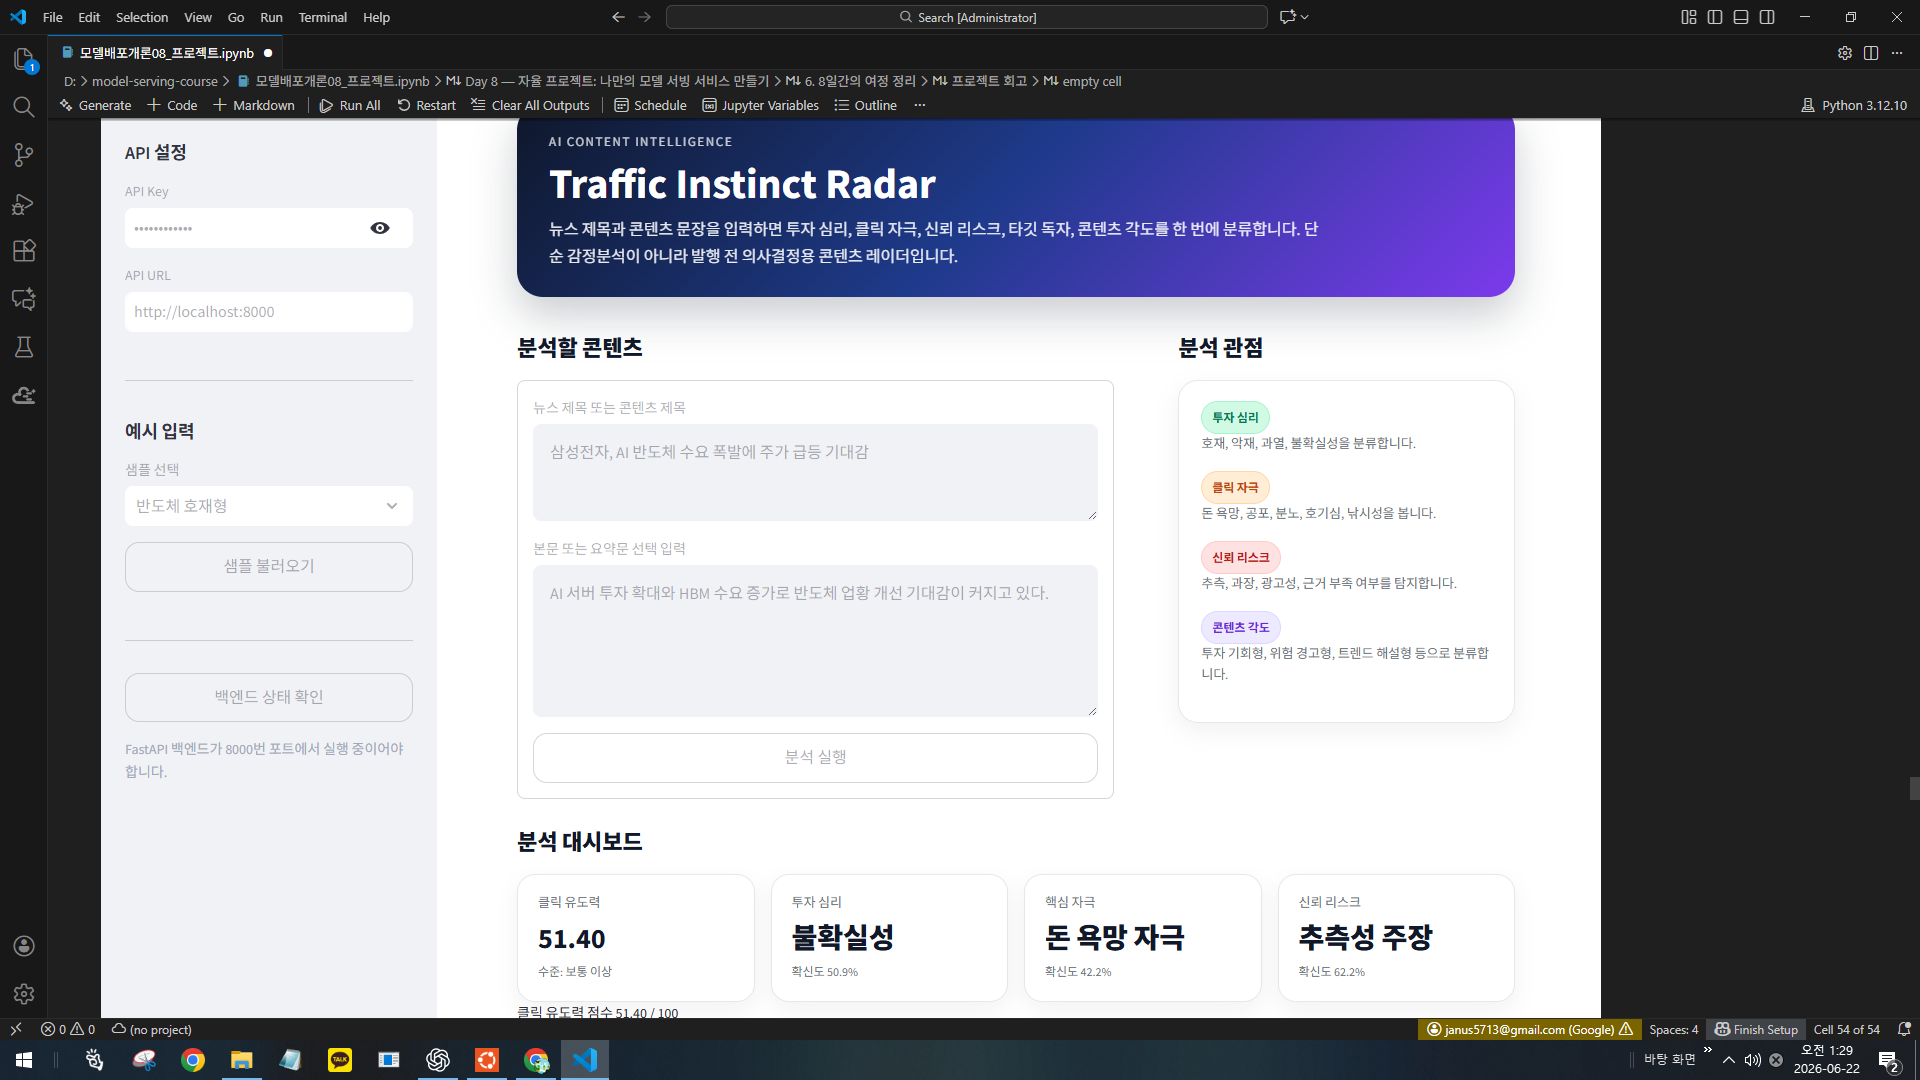
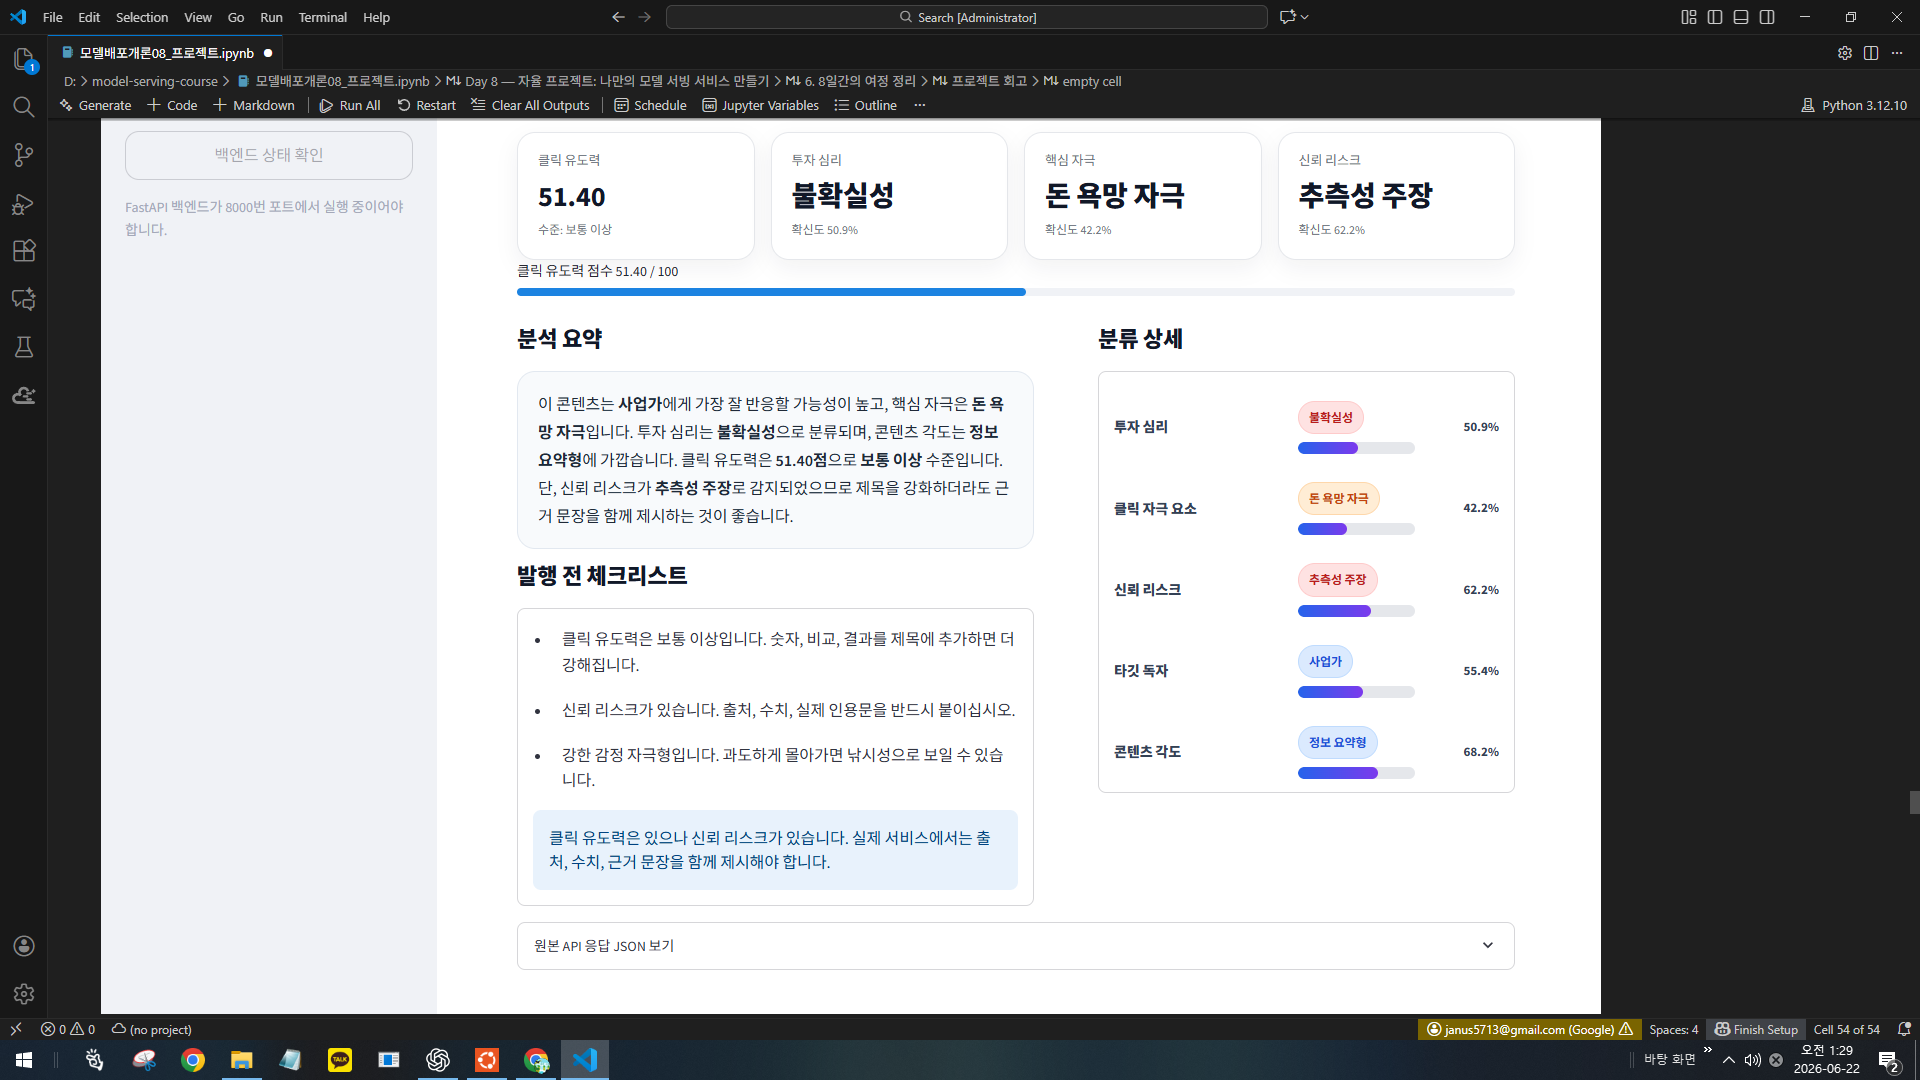